# Temas Tratados en el Trabajo Práctico 2

* Conceptos de Búsqueda no Informada y Búsqueda Informada.

* Concepto de Heurística.

* Abstracción de Problemas como Gráficos de Árbol.

* Estrategias de Búsqueda no Informada: Primero en Amplitud, Primero en Profundidad y Profundidad Limitada.

* Estrategias de Búsqueda Informada: Búsqueda Voraz, Costo Uniforme, A*.


## Ejercicios Teóricos

###1. ¿Qué diferencia hay entre una estrategia de búsqueda Informada y una estrategia de búsqueda No Informada?

Una **búsqueda no informada** no posee información adicional sobre qué estados pueden ser más convenientes para alcanzar el objetivo. El algoritmo conoce únicamente la definición del problema, como el estado inicial, las acciones posibles, los estados sucesores y el test objetivo, por lo que explora siguiendo la estrategia definida.

En cambio, una **búsqueda informada** dispone de información adicional relacionada con el objetivo que se quiere alcanzar. Esta información permite orientar la búsqueda hacia los estados que parecen más prometedores y, por lo tanto, puede hacerla más eficiente.

Por ejemplo, las búsquedas en amplitud y profundidad son estrategias no informadas, mientras que la búsqueda voraz y A* son estrategias informadas.

###2. ¿Qué es una heurística y para qué sirve?

Una **heurística** es una función que proporciona información adicional relacionada con el objetivo del problema. Puede entenderse como una **guía para llegar al objetivo**, ya que permite estimar qué tan conveniente o prometedor es un estado, pero no entrega directamente la solución.

La función heurística, representada como `h(n)`, estima el costo del camino desde un nodo `n` hasta el estado objetivo. Esta información permite orientar una búsqueda informada y decidir qué nodos conviene explorar primero.

Por ejemplo, en un problema de búsqueda de rutas se puede utilizar como heurística la distancia en línea recta desde la posición actual hasta el destino.

###3. ¿Es posible que un algoritmo de búsqueda no tenga solución?

Sí. Puede ocurrir que el problema planteado **no tenga ningún camino que permita llegar desde el estado inicial hasta el estado objetivo**, por lo que no existiría una solución que el algoritmo pueda encontrar.

También puede suceder que una solución exista, pero que determinadas estrategias de búsqueda no logren encontrarla. Esto está relacionado con el concepto de **completitud**.

Un algoritmo es **completo** cuando garantiza encontrar una solución siempre que ésta exista. Por el contrario, un algoritmo que no es completo puede no encontrarla incluso cuando el problema sí posee una solución. Por ejemplo, una búsqueda en profundidad puede continuar indefinidamente por una rama y no llegar a explorar aquella donde se encuentra el objetivo.

###4. Describa en qué secuencia será recorrido el Árbol de Búsqueda representado en la imagen cuando se aplica un Algoritmo de Búsqueda con la estrategia:

        4.1 Primero en Amplitud.

        4.2 Primero en Profundidad.

        4.3 Primero en Profundidad con Profundidad Limitada Iterativa (comenzando por un nivel de profundidad 1).

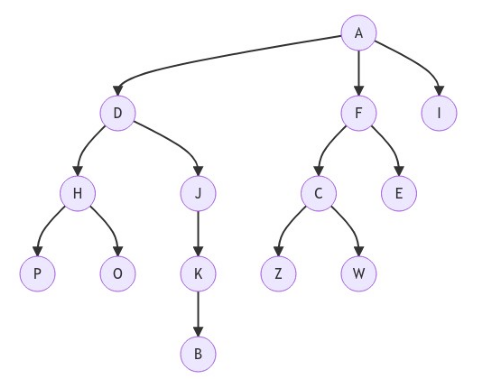

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1IJDEKWhfMEzXnzr28RgTNOuKBER2NsuP"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

Muestre la respuesta en una tabla, indicando para cada paso que da el agente el nodo que evalúa actualmente y los que están en la pila/cola de expansión según corresponda.

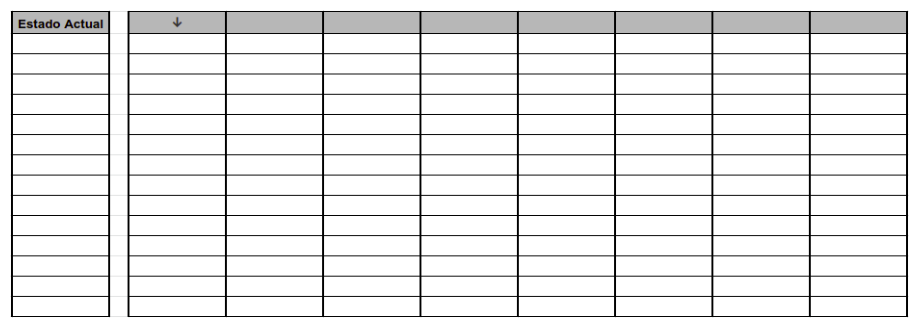

In [ ]:
url = "https://drive.google.com/uc?export=view&id=1fW_BgT5muzQffMVRcIiB2mM2Zf66Nb-m"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar con figura más grande
plt.figure(figsize=(img.width / 80, img.height / 80))  # ajustá el divisor según densidad deseada
plt.imshow(img)
plt.axis('off')
plt.show()

### 4.1 Primero en Amplitud

La búsqueda primero en amplitud recorre el árbol por niveles, de arriba hacia abajo y de izquierda a derecha. Para almacenar los nodos pendientes de expansión se utiliza una cola FIFO (First In, First Out).

| Paso | Nodo evaluado | Cola de expansión |
|------|---------------|-------------------|
| 1 | A | D, F, I |
| 2 | D | F, I, H, J |
| 3 | F | I, H, J, C, E |
| 4 | I | H, J, C, E |
| 5 | H | J, C, E, P, O |
| 6 | J | C, E, P, O, K |
| 7 | C | E, P, O, K, Z, W |
| 8 | E | P, O, K, Z, W |
| 9 | P | O, K, Z, W |
| 10 | O | K, Z, W |
| 11 | K | Z, W, B |
| 12 | Z | W, B |
| 13 | W | B |
| 14 | B | — |

**Secuencia de recorrido:**  
A → D → F → I → H → J → C → E → P → O → K → Z → W → B

### 4.2 Primero en Profundidad

La búsqueda primero en profundidad recorre cada rama del árbol hasta llegar lo más profundo posible antes de retroceder y continuar con otra rama. Para almacenar los nodos pendientes de expansión se utiliza una pila LIFO (Last In, First Out).

En la columna **Pila de expansión**, el primer elemento indicado corresponde al próximo nodo que será evaluado.

| Paso | Nodo evaluado | Pila de expansión |
|------|---------------|-------------------|
| 1 | A | D, F, I |
| 2 | D | H, J, F, I |
| 3 | H | P, O, J, F, I |
| 4 | P | O, J, F, I |
| 5 | O | J, F, I |
| 6 | J | K, F, I |
| 7 | K | B, F, I |
| 8 | B | F, I |
| 9 | F | C, E, I |
| 10 | C | Z, W, E, I |
| 11 | Z | W, E, I |
| 12 | W | E, I |
| 13 | E | I |
| 14 | I | — |

**Secuencia de recorrido:**  
A → D → H → P → O → J → K → B → F → C → Z → W → E → I

### 4.3 Primero en Profundidad con Profundidad Limitada Iterativa

La búsqueda en profundidad con profundidad limitada iterativa realiza varias búsquedas en profundidad, comenzando con un límite pequeño y aumentándolo progresivamente. En cada nueva iteración la búsqueda vuelve a comenzar desde el nodo raíz.

Se comienza con un límite de profundidad `l = 1` y se incrementa hasta alcanzar la máxima profundidad necesaria.

---

#### Iteración 1 — Límite de profundidad l = 1

Solo se pueden evaluar los nodos de profundidad 0 y 1. Los nodos ubicados en el nivel 1 se evalúan, pero no se expanden.

| Paso | Nodo evaluado | Profundidad | Pila de expansión |
|------|---------------|-------------|--------------------|
| 1 | A | 0 | D, F, I |
| 2 | D | 1 | F, I |
| 3 | F | 1 | I |
| 4 | I | 1 | — |

**Secuencia de recorrido:**  
A → D → F → I

---

#### Iteración 2 — Límite de profundidad l = 2

Ahora se permite expandir los nodos del nivel 1 y alcanzar los nodos del nivel 2.

| Paso | Nodo evaluado | Profundidad | Pila de expansión |
|------|---------------|-------------|--------------------|
| 1 | A | 0 | D, F, I |
| 2 | D | 1 | H, J, F, I |
| 3 | H | 2 | J, F, I |
| 4 | J | 2 | F, I |
| 5 | F | 1 | C, E, I |
| 6 | C | 2 | E, I |
| 7 | E | 2 | I |
| 8 | I | 1 | — |

**Secuencia de recorrido:**  
A → D → H → J → F → C → E → I

---

#### Iteración 3 — Límite de profundidad l = 3

Ahora se permite llegar hasta los nodos ubicados en profundidad 3.

| Paso | Nodo evaluado | Profundidad | Pila de expansión |
|------|---------------|-------------|--------------------|
| 1 | A | 0 | D, F, I |
| 2 | D | 1 | H, J, F, I |
| 3 | H | 2 | P, O, J, F, I |
| 4 | P | 3 | O, J, F, I |
| 5 | O | 3 | J, F, I |
| 6 | J | 2 | K, F, I |
| 7 | K | 3 | F, I |
| 8 | F | 1 | C, E, I |
| 9 | C | 2 | Z, W, E, I |
| 10 | Z | 3 | W, E, I |
| 11 | W | 3 | E, I |
| 12 | E | 2 | I |
| 13 | I | 1 | — |

**Secuencia de recorrido:**  
A → D → H → P → O → J → K → F → C → Z → W → E → I

---

#### Iteración 4 — Límite de profundidad l = 4

Finalmente se permite alcanzar la profundidad 4, por lo que se recorre todo el árbol.

| Paso | Nodo evaluado | Profundidad | Pila de expansión |
|------|---------------|-------------|--------------------|
| 1 | A | 0 | D, F, I |
| 2 | D | 1 | H, J, F, I |
| 3 | H | 2 | P, O, J, F, I |
| 4 | P | 3 | O, J, F, I |
| 5 | O | 3 | J, F, I |
| 6 | J | 2 | K, F, I |
| 7 | K | 3 | B, F, I |
| 8 | B | 4 | F, I |
| 9 | F | 1 | C, E, I |
| 10 | C | 2 | Z, W, E, I |
| 11 | Z | 3 | W, E, I |
| 12 | W | 3 | E, I |
| 13 | E | 2 | I |
| 14 | I | 1 | — |

**Secuencia de recorrido:**  
A → D → H → P → O → J → K → B → F → C → Z → W → E → I

## Ejercicios de Implementación

###5. Represente el tablero mostrado en la imágen como un árbol de búsqueda y a continuación programe un agente capaz de navegar por el tablero para llegar desde la casilla I a la casilla F utilizando:

        5.1 La estrategia Primero en Profundidad.

        5.2 La estrategia Avara.

        5.3 La estrategia A*.

Considere los siguientes comportamientos del agente:

* El agente no podrá moverse a las casillas siguientes si las separa una pared.

* La heurística empleada en el problema es la Distancia de Manhattan hasta la casilla objetivo (el menor número de casillas adyacentes entre la casilla actual y la casilla objetivo).

* El costo de atravesar una casilla es de 1, a excepción de la casilla W, cuyo costo al atravesarla es 30.

* En caso de que varias casillas tengan el mismo valor para ser expandidas, el algoritmo eligirá en orden alfabético las casillas que debe visitar.

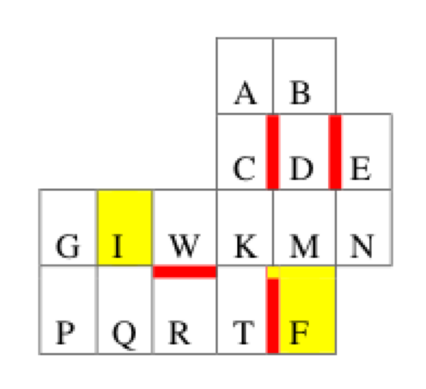

In [ ]:
url = "https://drive.google.com/uc?export=view&id=1FajYiBQ507o6yiE7MndL-PQXyoyELtuD"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

Para resolver el problema se representa el tablero mediante un conjunto de celdas conectadas entre sí. Cada celda posee un nombre, una posición, un costo y un conjunto de vecinos accesibles.

Las paredes se representan evitando la conexión entre las celdas que separan.

A partir de esta representación, el agente genera un árbol de búsqueda. Cada nodo del árbol almacena la celda correspondiente, su nodo padre y los costos necesarios para aplicar las distintas estrategias.

Se utilizarán las siguientes estrategias:

- Primero en Profundidad.
- Búsqueda Avara.
- Búsqueda A*.

Cuando sea necesario elegir entre nodos equivalentes, se utilizará orden alfabético.

El costo de ingresar a cualquier celda es `1`, excepto la celda `W`, cuyo costo es `30`. El costo de la celda inicial `I` no se contabiliza, ya que el agente comienza en ella.

In [1]:
from heapq import heappush, heappop
from itertools import count
import matplotlib.pyplot as plt


# ============================================================
# CELDA
# ============================================================

class Celda:
    """
    Representa una casilla del tablero.
    """

    def __init__(self, nombre, posicion, costo=1):
        self.nombre = nombre
        self.posicion = posicion
        self.costo = costo
        self.vecinos = {}

    def agregar_vecino(self, celda):
        """
        Agrega una celda vecina accesible.
        """
        self.vecinos[celda.nombre] = celda

    def obtener_vecinos_ordenados(self):
        """
        Devuelve los vecinos en orden alfabético.
        """
        return [
            self.vecinos[nombre]
            for nombre in sorted(self.vecinos)
        ]


# ============================================================
# NODO DEL ÁRBOL DE BÚSQUEDA
# ============================================================

class NodoBusqueda:
    """
    Representa un nodo generado durante la búsqueda.
    """

    def __init__(self, celda, padre=None, g=0, h=0):
        self.celda = celda
        self.padre = padre

        # Costo real acumulado desde el inicio.
        self.g = g

        # Estimación heurística hasta el objetivo.
        self.h = h

    @property
    def f(self):
        """
        Función de evaluación utilizada por A*.
        """
        return self.g + self.h

    def reconstruir_camino(self):
        """
        Reconstruye el camino desde el nodo inicial.
        """

        camino = []
        actual = self

        while actual is not None:
            camino.append(actual.celda.nombre)
            actual = actual.padre

        return list(reversed(camino))


# ============================================================
# RESULTADO DE UNA BÚSQUEDA
# ============================================================

class ResultadoBusqueda:
    """
    Almacena los resultados obtenidos por un algoritmo.
    """

    def __init__(
        self,
        estrategia,
        camino,
        expandidos,
        costo_total
    ):
        self.estrategia = estrategia
        self.camino = camino
        self.expandidos = expandidos
        self.costo_total = costo_total


# ============================================================
# TABLERO
# ============================================================

class Tablero:
    """
    Contiene las celdas y las conexiones del problema.
    """

    def __init__(self):
        self.celdas = {}

    def agregar_celda(
        self,
        nombre,
        fila,
        columna,
        costo=1
    ):
        self.celdas[nombre] = Celda(
            nombre,
            (fila, columna),
            costo
        )

    def conectar(self, nombre_a, nombre_b):
        """
        Conecta dos celdas en ambos sentidos.
        """

        celda_a = self.celdas[nombre_a]
        celda_b = self.celdas[nombre_b]

        celda_a.agregar_vecino(celda_b)
        celda_b.agregar_vecino(celda_a)

    def obtener(self, nombre):
        return self.celdas[nombre]

    @staticmethod
    def distancia_manhattan(origen, destino):
        """
        Calcula la distancia de Manhattan entre dos celdas.
        """

        fila_1, columna_1 = origen.posicion
        fila_2, columna_2 = destino.posicion

        return (
            abs(fila_1 - fila_2)
            + abs(columna_1 - columna_2)
        )

    def mostrar_conexiones(self):
        """
        Muestra los vecinos accesibles de cada celda.
        """

        for nombre in sorted(self.celdas):

            vecinos = (
                self.celdas[nombre]
                .obtener_vecinos_ordenados()
            )

            nombres = [
                vecino.nombre
                for vecino in vecinos
            ]

            print(
                f"{nombre} -> {', '.join(nombres)}"
            )

### Representación del tablero

Cada casilla del tablero se representa mediante un objeto de la clase `Celda`.

La posición se expresa mediante `(fila, columna)` y se utiliza posteriormente para calcular la distancia de Manhattan.

Dos celdas son vecinas únicamente cuando el agente puede desplazarse directamente entre ellas. Por lo tanto, cuando existe una pared entre dos casillas, estas no se conectan.

La celda `W` posee un costo especial de `30`, mientras que todas las demás poseen costo `1`.

In [4]:
# ============================================================
# CONSTRUCCIÓN DEL TABLERO
# ============================================================

def construir_tablero():

    tablero = Tablero()

    # --------------------------------------------------------
    # Posiciones
    # --------------------------------------------------------

    posiciones = {
        "A": (0, 3),
        "B": (0, 4),

        "C": (1, 3),
        "D": (1, 4),
        "E": (1, 5),

        "G": (2, 0),
        "I": (2, 1),
        "W": (2, 2),
        "K": (2, 3),
        "M": (2, 4),
        "N": (2, 5),

        "P": (3, 0),
        "Q": (3, 1),
        "R": (3, 2),
        "T": (3, 3),
        "F": (3, 4)
    }

    # Crear las celdas.
    for nombre, posicion in posiciones.items():

        fila, columna = posicion

        # W tiene un costo especial.
        if nombre == "W":
            costo = 30
        else:
            costo = 1

        tablero.agregar_celda(
            nombre,
            fila,
            columna,
            costo
        )

    # --------------------------------------------------------
    # Conexiones permitidas
    # --------------------------------------------------------
    #
    # Si dos celdas están separadas por una pared,
    # simplemente no se conectan.
    # --------------------------------------------------------

    conexiones = [
        ("A", "B"),
        ("A", "C"),

        ("B", "D"),

        ("C", "K"),

        ("D", "M"),

        ("E", "N"),

        ("G", "I"),
        ("G", "P"),

        ("I", "Q"),
        ("I", "W"),

        ("W", "K"),

        ("K", "M"),
        ("K", "T"),

        ("M", "N"),
        ("M", "F"),

        ("P", "Q"),

        ("Q", "R"),

        ("R", "T")
    ]

    for origen, destino in conexiones:
        tablero.conectar(origen, destino)

    return tablero


# Crear el tablero.
tablero = construir_tablero()

# Mostrar las conexiones.
tablero.mostrar_conexiones()

A -> B, C
B -> A, D
C -> A, K
D -> B, M
E -> N
F -> M
G -> I, P
I -> G, Q, W
K -> C, M, T, W
M -> D, F, K, N
N -> E, M
P -> G, Q
Q -> I, P, R
R -> Q, T
T -> K, R
W -> I, K


### Agente de búsqueda

Se implementa una única clase `AgenteBusqueda` que trabaja sobre el mismo tablero y contiene los tres métodos solicitados.

De esta manera no es necesario repetir la representación del problema para cada estrategia.

Cada estrategia cambia únicamente el criterio utilizado para elegir el próximo nodo de la frontera.

In [18]:
# ============================================================
# AGENTE DE BÚSQUEDA
# ============================================================

class AgenteBusqueda:

    def __init__(self, tablero):
        self.tablero = tablero


    # --------------------------------------------------------
    # CREAR RESULTADO
    # --------------------------------------------------------

    @staticmethod
    def crear_resultado(
        estrategia,
        nodo,
        expandidos
    ):

        return ResultadoBusqueda(
            estrategia,
            nodo.reconstruir_camino(),
            expandidos,
            nodo.g
        )


    # ========================================================
    # 5.1 PRIMERO EN PROFUNDIDAD
    # ========================================================

    def profundidad(self, inicio, objetivo):

      celda_inicial = self.tablero.obtener(inicio)

      visitados = set()
      expandidos = []

      def dfs(celda, padre=None, costo=0):

          # Marcar el nodo cuando realmente se visita.
          visitados.add(celda.nombre)
          expandidos.append(celda.nombre)

          nodo_actual = NodoBusqueda(
              celda=celda,
              padre=padre,
              g=costo
          )

          # Test objetivo.
          if celda.nombre == objetivo:
              return nodo_actual

          # Los vecinos ya vienen ordenados alfabéticamente.
          vecinos = celda.obtener_vecinos_ordenados()

          for vecino in vecinos:

              if vecino.nombre not in visitados:

                  resultado = dfs(
                      vecino,
                      nodo_actual,
                      costo + vecino.costo
                  )

                  if resultado is not None:
                      return resultado

          # Esta rama no condujo al objetivo.
          return None


      nodo_objetivo = dfs(celda_inicial)

      if nodo_objetivo is None:
          return None

      return self.crear_resultado(
          "Primero en profundidad",
          nodo_objetivo,
          expandidos
      )


    # ========================================================
    # 5.2 BÚSQUEDA AVARA
    # ========================================================

    def avara(self, inicio, objetivo):

        celda_inicial = self.tablero.obtener(
            inicio
        )

        celda_objetivo = self.tablero.obtener(
            objetivo
        )

        contador = count()

        h_inicial = (
            self.tablero.distancia_manhattan(
                celda_inicial,
                celda_objetivo
            )
        )

        nodo_inicial = NodoBusqueda(
            celda=celda_inicial,
            h=h_inicial
        )

        # Cola de prioridad.
        frontera = []

        # Prioridad:
        # 1. Menor h(n)
        # 2. Orden alfabético
        heappush(
            frontera,
            (
                nodo_inicial.h,
                celda_inicial.nombre,
                next(contador),
                nodo_inicial
            )
        )

        descubiertos = {inicio}
        expandidos = []

        while frontera:

            _, _, _, nodo_actual = heappop(
                frontera
            )

            expandidos.append(
                nodo_actual.celda.nombre
            )

            # Test objetivo.
            if nodo_actual.celda.nombre == objetivo:

                return self.crear_resultado(
                    "Búsqueda avara",
                    nodo_actual,
                    expandidos
                )

            vecinos = (
                nodo_actual.celda
                .obtener_vecinos_ordenados()
            )

            for vecino in vecinos:

                if vecino.nombre not in descubiertos:

                    descubiertos.add(
                        vecino.nombre
                    )

                    h = (
                        self.tablero
                        .distancia_manhattan(
                            vecino,
                            celda_objetivo
                        )
                    )

                    nuevo_nodo = NodoBusqueda(
                        celda=vecino,
                        padre=nodo_actual,
                        g=(
                            nodo_actual.g
                            + vecino.costo
                        ),
                        h=h
                    )

                    heappush(
                        frontera,
                        (
                            h,
                            vecino.nombre,
                            next(contador),
                            nuevo_nodo
                        )
                    )

        return None


    # ========================================================
    # 5.3 BÚSQUEDA A*
    # ========================================================

    def a_estrella(self, inicio, objetivo):

        celda_inicial = self.tablero.obtener(
            inicio
        )

        celda_objetivo = self.tablero.obtener(
            objetivo
        )

        contador = count()

        h_inicial = (
            self.tablero.distancia_manhattan(
                celda_inicial,
                celda_objetivo
            )
        )

        nodo_inicial = NodoBusqueda(
            celda=celda_inicial,
            h=h_inicial
        )

        frontera = []

        # Prioridad:
        # 1. Menor f(n) = g(n) + h(n)
        # 2. Orden alfabético
        heappush(
            frontera,
            (
                nodo_inicial.f,
                celda_inicial.nombre,
                next(contador),
                nodo_inicial
            )
        )

        # Mejor costo conocido para llegar
        # a cada celda.
        mejor_g = {
            inicio: 0
        }

        cerrados = set()
        expandidos = []

        while frontera:

            _, _, _, nodo_actual = heappop(
                frontera
            )

            nombre_actual = (
                nodo_actual.celda.nombre
            )

            # Evitar volver a expandir nodos cerrados.
            if nombre_actual in cerrados:
                continue

            # Ignorar una ruta antigua si ya se encontró
            # una mejor para esta misma celda.
            if (
                nodo_actual.g
                != mejor_g.get(nombre_actual)
            ):
                continue

            cerrados.add(nombre_actual)

            expandidos.append(nombre_actual)

            # Test objetivo.
            if nombre_actual == objetivo:

                return self.crear_resultado(
                    "A*",
                    nodo_actual,
                    expandidos
                )

            vecinos = (
                nodo_actual.celda
                .obtener_vecinos_ordenados()
            )

            for vecino in vecinos:

                if vecino.nombre in cerrados:
                    continue

                nuevo_g = (
                    nodo_actual.g
                    + vecino.costo
                )

                costo_anterior = mejor_g.get(
                    vecino.nombre,
                    float("inf")
                )

                # Si encontramos un camino mejor,
                # actualizamos el nodo.
                if nuevo_g < costo_anterior:

                    mejor_g[
                        vecino.nombre
                    ] = nuevo_g

                    h = (
                        self.tablero
                        .distancia_manhattan(
                            vecino,
                            celda_objetivo
                        )
                    )

                    nuevo_nodo = NodoBusqueda(
                        celda=vecino,
                        padre=nodo_actual,
                        g=nuevo_g,
                        h=h
                    )

                    heappush(
                        frontera,
                        (
                            nuevo_nodo.f,
                            vecino.nombre,
                            next(contador),
                            nuevo_nodo
                        )
                    )

        return None

In [19]:
# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

def mostrar_resultado(resultado):

    if resultado is None:
        print("No se encontró una solución.")
        return

    print(
        f"Estrategia: {resultado.estrategia}"
    )

    print(
        "Nodos expandidos:",
        " -> ".join(resultado.expandidos)
    )

    print(
        "Camino encontrado:",
        " -> ".join(resultado.camino)
    )

    print(
        f"Costo total: {resultado.costo_total}"
    )


# Crear el agente que utilizarán los tres incisos.
agente = AgenteBusqueda(tablero)

inicio = "I"
objetivo = "F"

### 5.1 Búsqueda Primero en Profundidad

La búsqueda primero en profundidad utiliza una estructura LIFO, por lo que intenta avanzar lo máximo posible por una rama antes de retroceder.

En este caso, cuando existen varios vecinos disponibles, se prioriza el orden alfabético.

Esta estrategia no utiliza la heurística ni el costo acumulado para decidir qué nodo expandir.

In [20]:
resultado_dfs = agente.profundidad(
    inicio,
    objetivo
)

mostrar_resultado(resultado_dfs)

Estrategia: Primero en profundidad
Nodos expandidos: I -> G -> P -> Q -> R -> T -> K -> C -> A -> B -> D -> M -> F
Camino encontrado: I -> G -> P -> Q -> R -> T -> K -> C -> A -> B -> D -> M -> F
Costo total: 12


#### Resultado

La búsqueda primero en profundidad encontró el camino:

**I → Q → R → T → K → M → F**

con un costo total de **6**.

Sin embargo, antes de alcanzar el objetivo expandió otros nodos que no forman parte del camino solución, ya que esta estrategia prioriza avanzar en profundidad y no utiliza información sobre la cercanía al objetivo.

### 5.2 Búsqueda Avara

La búsqueda avara es una estrategia informada que utiliza únicamente la función heurística:

$$
f(n)=h(n)
$$

En este problema se utiliza como heurística la **distancia de Manhattan** hasta la casilla `F`.

Por lo tanto, en cada paso se selecciona de la frontera la celda con menor valor de `h(n)`. Si varias celdas poseen el mismo valor, se seleccionan en orden alfabético.

La búsqueda avara no utiliza el costo acumulado `g(n)` para decidir qué nodo expandir.

In [21]:
resultado_avara = agente.avara(
    inicio,
    objetivo
)

mostrar_resultado(resultado_avara)

Estrategia: Búsqueda avara
Nodos expandidos: I -> Q -> R -> T -> K -> M -> F
Camino encontrado: I -> Q -> R -> T -> K -> M -> F
Costo total: 6


#### Resultado

La búsqueda avara encontró el camino:

**I → Q → R → T → K → M → F**

con un costo total de **6**.

A diferencia de la búsqueda en profundidad, la estrategia avara utiliza la distancia de Manhattan como guía y expande directamente nodos que parecen acercarla al objetivo.

El costo especial de `W` no interviene en la selección de nodos de esta estrategia, ya que la búsqueda avara utiliza únicamente `h(n)`.

### 5.3 Búsqueda A*

La búsqueda A* utiliza una función de evaluación que combina el costo real acumulado y la estimación heurística:

$$
f(n)=g(n)+h(n)
$$

donde:

- `g(n)` es el costo acumulado desde la casilla inicial hasta el nodo actual.
- `h(n)` es la distancia de Manhattan estimada desde el nodo actual hasta el objetivo.
- `f(n)` representa la estimación del costo total de una solución que pasa por ese nodo.

Al considerar `g(n)`, A* tiene en cuenta que atravesar la celda `W` posee un costo de `30`.

En caso de empate en el valor de `f(n)`, se utiliza el orden alfabético.

In [11]:
resultado_a_estrella = agente.a_estrella(
    inicio,
    objetivo
)

mostrar_resultado(resultado_a_estrella)

Estrategia: A*
Nodos expandidos: I -> Q -> R -> T -> G -> K -> M -> F
Camino encontrado: I -> Q -> R -> T -> K -> M -> F
Costo total: 6


#### Resultado

La búsqueda A* encontró el camino:

**I → Q → R → T → K → M → F**

con un costo total de **6**.

A* combina el costo recorrido `g(n)` con la distancia estimada al objetivo `h(n)`. De esta manera puede considerar tanto qué tan lejos se encuentra el objetivo como cuánto costó llegar hasta cada estado.

La celda `W`, cuyo costo es `30`, resulta poco conveniente para A*, ya que su elevado costo aumenta considerablemente el valor de `g(n)` y, por lo tanto, también el valor de `f(n)`.

### Comparación de las estrategias

Las tres estrategias alcanzan el mismo camino solución en este tablero:

**I → Q → R → T → K → M → F**

con costo total **6**.

Sin embargo, el procedimiento utilizado para encontrarlo es diferente:

| Estrategia | Criterio de selección | Información utilizada |
|---|---|---|
| Primero en Profundidad | Nodo más profundo | No utiliza heurística |
| Avara | Menor `h(n)` | Distancia estimada al objetivo |
| A* | Menor `g(n) + h(n)` | Costo acumulado + heurística |

Por lo tanto, que en este caso las estrategias encuentren el mismo camino no significa que sean equivalentes. Cada una expande los nodos siguiendo un criterio diferente.

### Visualización de los caminos encontrados

Para facilitar la comparación entre las estrategias se representa gráficamente el tablero como un grafo.

Las líneas finas representan las conexiones posibles entre las celdas y la línea más gruesa representa el camino solución encontrado por el algoritmo.

La casilla inicial se identifica mediante un marcador cuadrado y el objetivo mediante una estrella.

In [24]:
# ============================================================
# VISUALIZACIÓN
# ============================================================

def dibujar_camino(tablero, resultado):

    plt.figure(figsize=(10, 6))

    # --------------------------------------------------------
    # Dibujar conexiones del grafo
    # --------------------------------------------------------

    conexiones_dibujadas = set()

    for celda in tablero.celdas.values():

        fila_1, columna_1 = celda.posicion

        for vecino in celda.vecinos.values():

            conexion = tuple(
                sorted(
                    (
                        celda.nombre,
                        vecino.nombre
                    )
                )
            )

            # Evitar dibujar dos veces la misma conexión.
            if conexion in conexiones_dibujadas:
                continue

            conexiones_dibujadas.add(conexion)

            fila_2, columna_2 = vecino.posicion

            plt.plot(
                [columna_1, columna_2],
                [-fila_1, -fila_2],
                color="black",
                linewidth=0.8,
                zorder=1
            )


    # --------------------------------------------------------
    # Dibujar el camino solución
    # --------------------------------------------------------

    for i in range(len(resultado.camino) - 1):

        actual = tablero.obtener(
            resultado.camino[i]
        )

        siguiente = tablero.obtener(
            resultado.camino[i + 1]
        )

        fila_1, columna_1 = actual.posicion
        fila_2, columna_2 = siguiente.posicion

        plt.plot(
            [columna_1, columna_2],
            [-fila_1, -fila_2],
            color="darkred",
            linewidth=3.5,
            zorder=2
        )


    # --------------------------------------------------------
    # Dibujar nodos
    # --------------------------------------------------------

    for celda in tablero.celdas.values():

        fila, columna = celda.posicion

        plt.scatter(
            columna,
            -fila,
            s=750,
            color="#123B5D",
            edgecolors="black",
            linewidths=1.2,
            zorder=3
        )

        etiqueta = celda.nombre

        # Mostrar el costo especial de W.
        if celda.nombre == "W":
            etiqueta += "\n30"

        plt.text(
            columna,
            -fila,
            etiqueta,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold",
            zorder=4
        )


    # --------------------------------------------------------
    # Identificar inicio y objetivo
    # --------------------------------------------------------

    celda_inicio = tablero.obtener(
        resultado.camino[0]
    )

    celda_final = tablero.obtener(
        resultado.camino[-1]
    )

    fila_i, columna_i = celda_inicio.posicion
    fila_f, columna_f = celda_final.posicion

    plt.text(
        columna_i,
        -fila_i - 0.38,
        "Inicio",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold"
    )

    plt.text(
        columna_f,
        -fila_f - 0.38,
        "Objetivo",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    plt.title(
        f"{resultado.estrategia}\n"
        f"Camino: {' → '.join(resultado.camino)}"
        f"   |   Costo: {resultado.costo_total}",
        fontsize=12,
        fontweight="bold"
    )

    plt.axis("equal")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

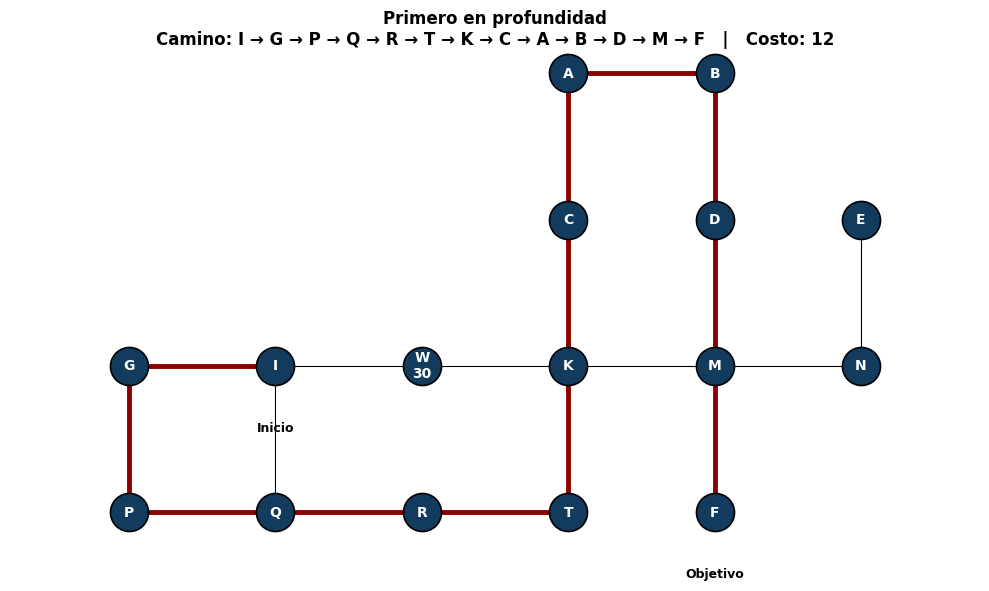

In [25]:
dibujar_camino(
    tablero,
    resultado_dfs
)

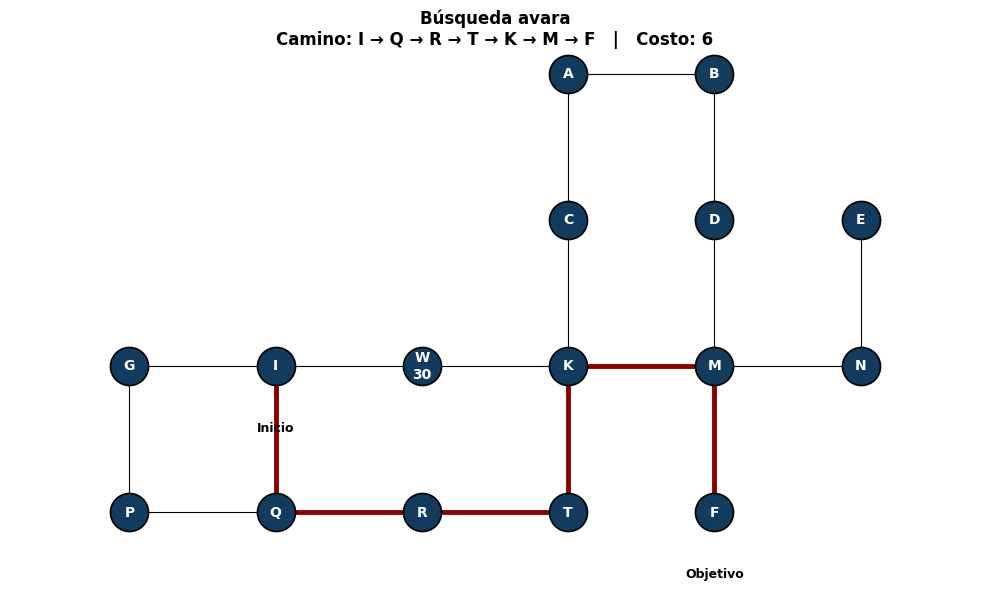

In [26]:
dibujar_camino(
    tablero,
    resultado_avara
)

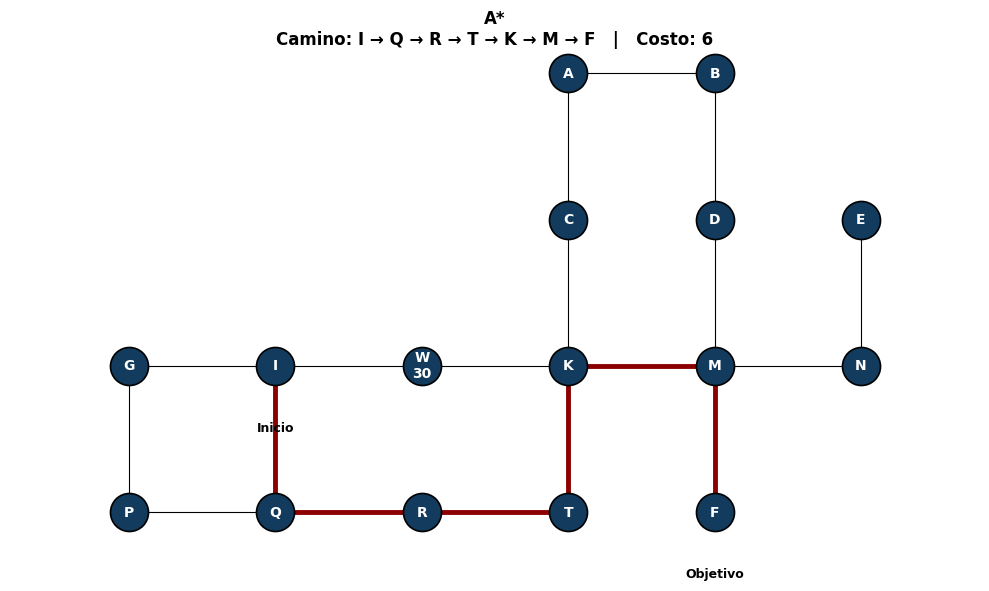

In [27]:
dibujar_camino(
    tablero,
    resultado_a_estrella
)

6. Desarrolle un agente que emplee una estrategia de búsqueda A* para ir de una casilla a otra evitando la pared representada, pudiendo seleccionar ustedes mismos el inicio y el final. Muestre en una imagen el camino obtenido.

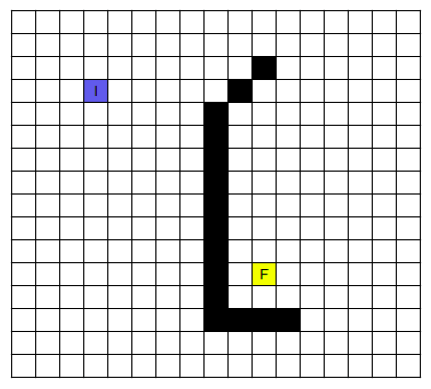

In [ ]:
url = "https://drive.google.com/uc?export=view&id=1fD2Ws5oqFU9_RTj-yX9BIvslXJiqcLCZ"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)